# 🔢 NumPy — The Engine of Scientific Python

> **What you'll learn:** how to store numbers in fast arrays, do math on millions of values without loops, reshape and combine data, use broadcasting, solve linear algebra problems, and build a real machine-learning model using nothing but NumPy.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Python Basics](../00_Foundations/01_Python_Basics.ipynb) (lists, loops, functions) |
| **Tested with** | Python 3.12 · numpy 2.5 · scikit-learn 1.9 (only for loading datasets) |
| **Interview relevance** | ⭐⭐⭐ High — "vectorize this loop", broadcasting shapes, views vs copies, implement softmax / distances / linear regression in NumPy |

## 🤔 What Is NumPy?

Imagine two ways to store 1 million exam scores:

- **A Python list** is like a filing cabinet where every score sits in its own envelope, with a label saying "this is a number". To add 1 to every score, Python opens each envelope, reads the label, does the math, and writes a new envelope.
- **A NumPy array** is like a single spreadsheet column: one block of memory, every cell the same type. To add 1 to every score, NumPy runs one tight, pre-compiled loop over the whole block.

**NumPy** (Numerical Python) gives you the `ndarray` — an *n-dimensional array* of values that all share one data type — plus hundreds of fast functions that work on whole arrays at once.

```
Python list  →  [ ptr ][ ptr ][ ptr ] ...     each ptr → a separate Python int object (~28 bytes)
NumPy array  →  [ 8B ][ 8B ][ 8B ] ...        raw numbers packed side by side
```

## 🎯 Why It Matters

- **Everything in AI/ML is built on it.** Pandas, scikit-learn, SciPy, Matplotlib, and the tensor APIs of PyTorch and JAX all copy NumPy's ideas (shapes, dtypes, broadcasting).
- **Speed.** Vectorized NumPy code is often **10–100× faster** than Python loops.
- **The language of data.** Images are `(height, width, 3)` arrays, a batch of sentences is `(batch, tokens, embedding_dim)`, a dataset is `(rows, features)`.
- **In interviews** you will be asked to *write* things like softmax, cosine similarity, pairwise distances, k-nearest neighbours, or linear regression **with only NumPy**, and to reason about shapes out loud. This notebook practises exactly that.

## ✅ By the End You Can

- [ ] Create arrays and explain `shape`, `dtype`, and memory use
- [ ] Select data with slicing, boolean masks, and fancy indexing — and know which ones copy
- [ ] Replace Python loops with vectorized math and the `axis` argument
- [ ] Predict the result shape of any broadcasting operation
- [ ] Solve linear systems and least-squares problems correctly
- [ ] Implement softmax, pairwise distances, k-NN, and linear regression from scratch

## 📋 Table of Contents

1. [Why NumPy? Lists vs Arrays](#1.-Why-NumPy?-Lists-vs-Arrays-🟢)
2. [Creating Arrays](#2.-Creating-Arrays-🟢)
3. [Shape, dtype, and Memory](#3.-Shape,-dtype,-and-Memory-🟢)
4. [Indexing and Slicing](#4.-Indexing-and-Slicing-🟢)
5. [Views vs Copies](#5.-Views-vs-Copies-🟡)
6. [Vectorized Math and ufuncs](#6.-Vectorized-Math-and-ufuncs-🟢)
7. [Aggregations and the `axis` Argument](#7.-Aggregations-and-the-axis-Argument-🟡)
8. [Broadcasting](#8.-Broadcasting-🟡)
9. [Reshaping and Combining Arrays](#9.-Reshaping-and-Combining-Arrays-🟡)
10. [Linear Algebra](#10.-Linear-Algebra-🟡)
11. [Random Numbers the Modern Way](#11.-Random-Numbers-the-Modern-Way-🟢)
12. [Sorting, Searching, and Counting](#12.-Sorting,-Searching,-and-Counting-🟢)
13. [Saving and Loading Arrays](#13.-Saving-and-Loading-Arrays-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Linear-Regression-From-Scratch) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If NumPy is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
%pip install -q "numpy>=2.0" "scikit-learn>=1.5" matplotlib

import sys
import time
from pathlib import Path

import numpy as np

print(f"Python {sys.version.split()[0]} | NumPy {np.__version__}")

rng = np.random.default_rng(42)            # one seeded random generator for the whole notebook
np.set_printoptions(precision=3, suppress=True)
OUTPUT_DIR = Path("_outputs")              # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    got_arr, exp_arr = np.asarray(got), np.asarray(expected)
    if got_arr.shape != exp_arr.shape:
        raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
    numeric = np.issubdtype(exp_arr.dtype, np.number) and exp_arr.dtype != bool
    ok = np.allclose(got_arr, exp_arr) if numeric else np.array_equal(got_arr, exp_arr)
    assert ok, f"❌ {name}: values are not quite right. {hint}"
    print(f"✅ {name}: correct!")

/Users/mayankpokhriyal/Workspaces/Learning-AI-ML/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.
Python 3.12.11 | NumPy 2.5.3


## 1. Why NumPy? Lists vs Arrays 🟢

Let's *measure* the difference instead of just claiming it. We square one million numbers both ways and compare time and memory.

In [2]:
n = 1_000_000
py_list = list(range(n))
np_arr = np.arange(n)

start = time.perf_counter()
squared_list = [x * x for x in py_list]
list_ms = (time.perf_counter() - start) * 1000

start = time.perf_counter()
squared_arr = np_arr * np_arr
numpy_ms = (time.perf_counter() - start) * 1000

print(f"Python list : {list_ms:7.1f} ms")
print(f"NumPy array : {numpy_ms:7.1f} ms   → about {list_ms / numpy_ms:.0f}× faster")

# Memory: a list stores pointers AND a separate Python int object per element
list_bytes = sys.getsizeof(py_list) + sum(sys.getsizeof(x) for x in py_list)
print(f"\nList memory : {list_bytes / 1e6:5.1f} MB")
print(f"Array memory: {np_arr.nbytes / 1e6:5.1f} MB  ({np_arr.dtype}: {np_arr.itemsize} bytes per number)")
print(f"→ the list uses about {list_bytes / np_arr.nbytes:.1f}× more memory")

Python list :    11.2 ms
NumPy array :     1.0 ms   → about 12× faster



List memory :  36.0 MB
Array memory:   8.0 MB  (int64: 8 bytes per number)
→ the list uses about 4.5× more memory


**Why is NumPy faster?**
1. **Contiguous memory** — numbers sit next to each other, which CPUs love (cache-friendly).
2. **One type for all elements** — no per-element "what type is this?" checks.
3. **Compiled loops** — the loop runs in C, not in the Python interpreter (and often uses SIMD CPU instructions).

> 💡 **Interview angle:** "Why is NumPy faster than a Python list?" — contiguous, homogeneous memory + loops in compiled code + no per-element type dispatch. Mention that `sys.getsizeof(list)` alone *under-counts* list memory because it ignores the element objects.

## 2. Creating Arrays 🟢

| Function | Creates | Example |
|---|---|---|
| `np.array(list)` | an array from Python data | `np.array([1, 2, 3])` |
| `np.zeros(shape)` / `np.ones(shape)` | all 0s / all 1s | `np.zeros((2, 3))` |
| `np.full(shape, value)` | all the same value | `np.full(3, 7)` |
| `np.arange(start, stop, step)` | evenly spaced by **step** (stop excluded) | `np.arange(0, 10, 2)` |
| `np.linspace(start, stop, num)` | **num** evenly spaced points (stop included) | `np.linspace(0, 1, 5)` |
| `np.eye(n)` | identity matrix | `np.eye(3)` |

In [3]:
print("from a list  :", np.array([3, 1, 4, 1, 5]))
print("2-D from list:\n", np.array([[1, 2, 3], [4, 5, 6]]))
print("zeros (2×3)  :\n", np.zeros((2, 3)))
print("full         :", np.full(4, 7.5))
print("arange       :", np.arange(0, 10, 2))       # stop (10) is NOT included
print("linspace     :", np.linspace(0, 1, 5))      # stop (1) IS included
print("identity     :\n", np.eye(3, dtype=int))

from a list  : [3 1 4 1 5]
2-D from list:
 [[1 2 3]
 [4 5 6]]
zeros (2×3)  :
 [[0. 0. 0.]
 [0. 0. 0.]]
full         : [7.5 7.5 7.5 7.5]
arange       : [0 2 4 6 8]
linspace     : [0.   0.25 0.5  0.75 1.  ]
identity     :
 [[1 0 0]
 [0 1 0]
 [0 0 1]]


### ✍️ Your Turn

Create `grid`: **5 evenly spaced numbers from 0 to 1, including both ends**.

In [4]:
grid = None  # TODO: your code here
check("grid", grid, [0.0, 0.25, 0.5, 0.75, 1.0], hint="Which function includes the stop value: arange or linspace?")

⏳ grid: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
grid = np.linspace(0, 1, 5)
check("grid", grid, [0.0, 0.25, 0.5, 0.75, 1.0])
```

`np.arange(0, 1.25, 0.25)` also works here, but floating-point steps in `arange` can produce an extra or missing element — prefer `linspace` when you know *how many* points you want.
</details>

> 💡 **Interview angle:** "`arange` vs `linspace`?" — `arange` fixes the *step* and excludes the stop; `linspace` fixes the *count* and includes the stop, so it is safe with floats.

## 3. Shape, dtype, and Memory 🟢

Every array has:
- **`ndim`** — number of dimensions (a vector has 1, a table has 2, a batch of images has 4)
- **`shape`** — size along each dimension, e.g. `(rows, columns)`
- **`dtype`** — the type of every element (`int64`, `float32`, `bool`, …)
- **`nbytes`** — memory used = number of elements × bytes per element

In [5]:
table = np.array([[1, 2, 3], [4, 5, 6]])
print(f"ndim={table.ndim}  shape={table.shape}  size={table.size}  dtype={table.dtype}  nbytes={table.nbytes}")

as_float32 = table.astype(np.float32)          # convert type (makes a new array)
print(f"float32 version uses {as_float32.nbytes} bytes (half of float64)")

mixed = np.array([1, 2.5, 3])                  # mixing ints and floats → everything becomes float
print("mixed dtype:", mixed.dtype)

# Small integer types have a limited range — values silently wrap around!
small = np.array([100, 120], dtype=np.int8)    # int8 range is -128..127
print("int8 100+100, 120+120 →", small + small)

ndim=2  shape=(2, 3)  size=6  dtype=int64  nbytes=48
float32 version uses 24 bytes (half of float64)
mixed dtype: float64
int8 100+100, 120+120 → [-56 -16]


> 💡 **Interview angle:** "Why do deep-learning models use `float32` or `float16` instead of `float64`?" — half (or a quarter) of the memory and faster GPU math, with precision that is still good enough for weights and gradients.

## 4. Indexing and Slicing 🟢

NumPy indexing starts at **0** and slicing is `start:stop:step` (stop excluded) — just like lists, but it works in **every dimension**, separated by commas: `M[row, column]`.

```
           col 0  col 1  col 2  col 3
  row 0  [   1      2      3      4  ]
  row 1  [   5      6      7      8  ]      M[1, 2] → 7
  row 2  [   9     10     11     12  ]      M[:, 2] → [3, 7, 11]
```

In [6]:
a = np.arange(10, 100, 10)                     # [10 20 30 40 50 60 70 80 90]
print("a        :", a)
print("a[0], a[-1]:", a[0], a[-1])
print("a[2:5]   :", a[2:5])
print("a[::2]   :", a[::2])
print("a[::-1]  :", a[::-1])

M = np.arange(1, 13).reshape(3, 4)
print("\nM:\n", M)
print("M[1, 2]      :", M[1, 2])
print("M[1]  (row 1):", M[1])
print("M[:, 2] (col):", M[:, 2])
print("M[:2, 1:3]   :\n", M[:2, 1:3])

a        : [10 20 30 40 50 60 70 80 90]
a[0], a[-1]: 10 90
a[2:5]   : [30 40 50]
a[::2]   : [10 30 50 70 90]
a[::-1]  : [90 80 70 60 50 40 30 20 10]

M:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
M[1, 2]      : 7
M[1]  (row 1): [5 6 7 8]
M[:, 2] (col): [ 3  7 11]
M[:2, 1:3]   :
 [[2 3]
 [6 7]]


**Boolean masks** select elements where a condition is `True`. **Fancy indexing** selects using a list/array of positions.

In [7]:
is_even = M % 2 == 0
print("mask:\n", is_even)
print("M[mask]            :", M[is_even])                  # always returns a 1-D array
print("M[(M > 3) & (M < 9)]:", M[(M > 3) & (M < 9)])      # use & | ~ with parentheses, not and/or
print("rows 0 and 2       :\n", M[[0, 2]])
print("elements (0,1),(2,3):", M[[0, 2], [1, 3]])

mask:
 [[False  True False  True]
 [False  True False  True]
 [False  True False  True]]
M[mask]            : [ 2  4  6  8 10 12]
M[(M > 3) & (M < 9)]: [4 5 6 7 8]
rows 0 and 2       :
 [[ 1  2  3  4]
 [ 9 10 11 12]]
elements (0,1),(2,3): [ 2 12]


### ✍️ Your Turn

From `scores`, select **only the scores that are 70 or higher** (keep their original order).

In [8]:
scores = np.array([55, 91, 78, 40, 88, 67])
passing = None  # TODO: your code here
check("passing", passing, [91, 78, 88], hint="Build a boolean mask with >= and use it inside [ ].")

⏳ passing: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
scores = np.array([55, 91, 78, 40, 88, 67])
passing = scores[scores >= 70]
check("passing", passing, [91, 78, 88])
```
</details>

## 5. Views vs Copies 🟡

This is the #1 source of confusing NumPy bugs — and a favourite interview question.

| Operation | Returns | Changing the result changes the original? |
|---|---|---|
| Basic slicing `a[1:4]`, `a[:, 0]` | **view** (shares memory) | **Yes** |
| `reshape`, `.T`, `ravel()` (when possible) | view | Yes |
| Boolean mask `a[a > 0]`, fancy index `a[[1, 2]]` | **copy** | No |
| `.copy()`, `flatten()`, `astype()` | copy | No |

Check with `np.shares_memory(a, b)`.

In [9]:
base = np.arange(6)
view = base[1:4]
view[0] = 100
print("after changing the SLICE :", base, "| shares memory:", np.shares_memory(base, view))

base = np.arange(6)
fancy = base[[1, 2, 3]]
fancy[0] = -1
print("after changing FANCY copy:", base, "| shares memory:", np.shares_memory(base, fancy))

reshaped = base.reshape(2, 3)
print("reshape shares memory    :", np.shares_memory(base, reshaped))
print("slice + .copy() shares   :", np.shares_memory(base, base[1:4].copy()))

after changing the SLICE : [  0 100   2   3   4   5] | shares memory: True
after changing FANCY copy: [0 1 2 3 4 5] | shares memory: False
reshape shares memory    : True
slice + .copy() shares   : False


**Why does NumPy do this?** Views make slicing a huge array instant and memory-free — no data is copied. The price is that you must add `.copy()` when you need an independent array.

### ✍️ Your Turn

Make `first_half` contain the first 5 elements of `data`, **independent of `data`**, so that zeroing `first_half` leaves `data` unchanged.

In [10]:
data = np.arange(10)
first_half = None  # TODO: your code here
if first_half is not None:
    first_half[:] = 0
check("independent_copy", None if first_half is None else data, np.arange(10),
      hint="Slicing gives a view that shares memory — what method makes it independent?")

⏳ independent_copy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
data = np.arange(10)
first_half = data[:5].copy()
first_half[:] = 0
check("independent_copy", data, np.arange(10))
```
</details>

> 💡 **Interview angle:** "I modified a slice and my original data changed — why?" — slices are views. Explain `np.shares_memory` and `.copy()`, and that boolean/fancy indexing already copies.

## 6. Vectorized Math and ufuncs 🟢

**Vectorization** = writing math on whole arrays instead of looping over elements. Arithmetic operators work element-by-element, and **ufuncs** (universal functions) like `np.sqrt`, `np.exp`, `np.log` do too.

In [11]:
prices = np.array([19.99, 5.49, 3.75, 12.00])
quantity = np.array([2, 10, 4, 1])

line_totals = prices * quantity                # element-wise multiply, no loop
print("line totals:", line_totals, "| order total:", line_totals.sum().round(2))

temps_c = np.array([-5.0, 12.5, 30.0, 41.2])
print("to Fahrenheit:", temps_c * 9 / 5 + 32)
print("sqrt, exp    :", np.sqrt(np.array([4, 9, 16])), np.exp(np.array([0.0, 1.0])))
print("where        :", np.where(temps_c > 30, "hot", "ok"))   # vectorized if/else
print("clip 0..35   :", np.clip(temps_c, 0, 35))

line totals: [39.98 54.9  15.   12.  ] | order total: 121.88
to Fahrenheit: [ 23.    54.5   86.   106.16]
sqrt, exp    : [2. 3. 4.] [1.    2.718]
where        : ['ok' 'ok' 'ok' 'hot']
clip 0..35   : [ 0.  12.5 30.  35. ]


In [12]:
# Loop vs vectorized: the sigmoid function used in logistic regression and neural networks
values = rng.normal(size=500_000)

start = time.perf_counter()
loop_result = np.array([1 / (1 + np.exp(-v)) for v in values])
loop_ms = (time.perf_counter() - start) * 1000

start = time.perf_counter()
vector_result = 1 / (1 + np.exp(-values))
vector_ms = (time.perf_counter() - start) * 1000

print(f"loop: {loop_ms:.0f} ms | vectorized: {vector_ms:.1f} ms | same result: {np.allclose(loop_result, vector_result)}")

loop: 68 ms | vectorized: 3.4 ms | same result: True


### ✍️ Your Turn

Implement **ReLU** (used in almost every neural network) without a loop: negative values become 0, positive values stay the same.

In [13]:
z = np.array([-2.0, -0.5, 0.0, 1.5, 3.0])
relu = None  # TODO: your code here
check("relu", relu, [0.0, 0.0, 0.0, 1.5, 3.0], hint="np.maximum compares element-wise against a number.")

⏳ relu: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
z = np.array([-2.0, -0.5, 0.0, 1.5, 3.0])
relu = np.maximum(z, 0)
check("relu", relu, [0.0, 0.0, 0.0, 1.5, 3.0])
```

`np.where(z > 0, z, 0)` and `np.clip(z, 0, None)` also work. Note `np.max` (largest value of one array) is different from `np.maximum` (element-wise max of two inputs).
</details>

## 7. Aggregations and the `axis` Argument 🟡

`sum`, `mean`, `std`, `min`, `max`, `argmax` reduce an array. The **`axis`** says which dimension gets *collapsed*:

```
                store0 store1 store2
  week0      [   120     80     95 ]
  week1      [   130     70    110 ]      axis=0 → collapse rows    → one value per STORE  (shape (3,))
  week2      [    90    100    105 ]      axis=1 → collapse columns → one value per WEEK   (shape (4,))
  week3      [   150     60    120 ]
```

In [14]:
sales = np.array([[120, 80, 95],
                  [130, 70, 110],
                  [90, 100, 105],
                  [150, 60, 120]])

print("total             :", sales.sum())
print("per store (axis=0):", sales.sum(axis=0))
print("per week  (axis=1):", sales.sum(axis=1))
print("mean per store    :", sales.mean(axis=0))
print("best store each week (argmax axis=1):", sales.argmax(axis=1))
print("running total store 0:", np.cumsum(sales[:, 0]))
print("keepdims shape    :", sales.sum(axis=1, keepdims=True).shape, "vs", sales.sum(axis=1).shape)

total             : 1230
per store (axis=0): [490 310 430]
per week  (axis=1): [295 310 295 330]
mean per store    : [122.5  77.5 107.5]
best store each week (argmax axis=1): [0 0 2 0]
running total store 0: [120 250 340 490]
keepdims shape    : (4, 1) vs (4,)


### ✍️ Your Turn

Normalize each **row** of `X` so that it sums to 1 — no loops. (This is exactly how you turn raw counts into probabilities.)

In [15]:
X = np.array([[1, 3],
              [2, 2]])
row_normalized = None  # TODO: your code here
check("row_normalized", row_normalized, [[0.25, 0.75], [0.5, 0.5]],
      hint="Divide by X.sum(axis=1, keepdims=True) so the shapes line up.")

⏳ row_normalized: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X = np.array([[1, 3], [2, 2]])
row_normalized = X / X.sum(axis=1, keepdims=True)
check("row_normalized", row_normalized, [[0.25, 0.75], [0.5, 0.5]])
```

Without `keepdims=True` the row sums have shape `(2,)`, which broadcasts across *columns* instead of rows — a silent bug when the matrix is square. The next section explains why.
</details>

> 💡 **Interview angle:** "What does `axis=0` mean?" — the axis that disappears. For a `(rows, features)` matrix, `axis=0` gives one value per feature (column statistics), `axis=1` one per row.

## 8. Broadcasting 🟡

**Broadcasting** lets NumPy combine arrays of different shapes *without copying data*. Line the shapes up **from the right**; each pair of dimensions must be **equal**, or one of them must be **1** (a missing dimension counts as 1). The size-1 dimension is stretched to match.

| Shape A | Shape B | Result | Why |
|---|---|---|---|
| `(3,)` | scalar `()` | `(3,)` | scalar stretches everywhere |
| `(4, 3)` | `(3,)` | `(4, 3)` | `(3,)` → `(1, 3)` → stretched over 4 rows |
| `(4, 1)` | `(1, 3)` | `(4, 3)` | both stretch |
| `(4, 3)` | `(4,)` | **error** | right-aligned: 3 vs 4 don't match |

In [16]:
features = np.array([[170.0, 65.0],
                     [180.0, 80.0],
                     [160.0, 55.0]])            # (3 people, 2 features: height cm, weight kg)

col_mean = features.mean(axis=0)               # shape (2,)
col_std = features.std(axis=0)                 # shape (2,)
standardized = (features - col_mean) / col_std # (3, 2) with (2,) → broadcasts over rows
print("standardized:\n", standardized)
print("column means now ≈ 0:", standardized.mean(axis=0))

# Outer operation: every row value combined with every column value
row = np.array([1, 2, 3])[:, np.newaxis]       # (3, 1)
col = np.array([10, 20])[np.newaxis, :]        # (1, 2)
print("\n(3,1) + (1,2) → (3,2):\n", row + col)

try:
    features + np.array([1.0, 2.0, 3.0])       # (3, 2) + (3,) — right-aligned 2 vs 3
except ValueError as err:
    print("\nBroadcast error:", err)

standardized:
 [[ 0.    -0.162]
 [ 1.225  1.298]
 [-1.225 -1.136]]
column means now ≈ 0: [ 0. -0.]

(3,1) + (1,2) → (3,2):
 [[11 21]
 [12 22]
 [13 23]]

Broadcast error: operands could not be broadcast together with shapes (3,2) (3,) 


### ✍️ Your Turn

Build a **5×5 multiplication table** (values 1–5 times 1–5) using broadcasting — no loops, no `np.outer`.

In [17]:
nums = np.arange(1, 6)
times_table = None  # TODO: your code here
check("times_table", times_table, [[i * j for j in range(1, 6)] for i in range(1, 6)],
      hint="Turn nums into a column (5,1) and a row (1,5), then multiply.")

⏳ times_table: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
nums = np.arange(1, 6)
times_table = nums[:, np.newaxis] * nums[np.newaxis, :]
check("times_table", times_table, [[i * j for j in range(1, 6)] for i in range(1, 6)])
```
</details>

> 💡 **Interview angle:** Say the rule out loud: *"align shapes from the right; dimensions must match or be 1."* Then predict the output shape **before** running code — interviewers love watching you reason about shapes.

## 9. Reshaping and Combining Arrays 🟡

- `reshape(new_shape)` — same data, new shape (use `-1` to let NumPy compute one dimension)
- `np.newaxis` / `None` — add a dimension of size 1
- `.T` — transpose (swap rows and columns)
- `ravel()` (view when possible) vs `flatten()` (always a copy)
- `np.concatenate` joins along an **existing** axis; `np.stack` creates a **new** axis

In [18]:
x = np.arange(12)
print("reshape(3, 4):\n", x.reshape(3, 4))
print("reshape(2, -1) shape:", x.reshape(2, -1).shape)
print("transpose shape     :", x.reshape(3, 4).T.shape)
print("add axis            :", x[:, np.newaxis].shape, x[np.newaxis, :].shape)
print("ravel is a view     :", np.shares_memory(x, x.reshape(3, 4).ravel()))
print("flatten is a copy   :", np.shares_memory(x, x.reshape(3, 4).flatten()))

a, b = np.array([1, 2, 3]), np.array([4, 5, 6])
print("\nconcatenate:", np.concatenate([a, b]))
print("stack axis 0:\n", np.stack([a, b]))
print("stack axis 1:\n", np.stack([a, b], axis=1))
print("split into 3:", np.split(x, 3))

# Real use: a batch of 8 grayscale 28×28 images → one row per image for a classic ML model
images = rng.random((8, 28, 28))
print("\nimages", images.shape, "→ flattened", images.reshape(len(images), -1).shape)

reshape(3, 4):
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
reshape(2, -1) shape: (2, 6)
transpose shape     : (4, 3)
add axis            : (12, 1) (1, 12)
ravel is a view     : True
flatten is a copy   : False

concatenate: [1 2 3 4 5 6]
stack axis 0:
 [[1 2 3]
 [4 5 6]]
stack axis 1:
 [[1 4]
 [2 5]
 [3 6]]
split into 3: [array([0, 1, 2, 3]), array([4, 5, 6, 7]), array([ 8,  9, 10, 11])]

images (8, 28, 28) → flattened (8, 784)


> 💡 **Interview angle:** "`reshape` vs `resize` vs `view`?" / "What does `-1` mean in reshape?" — `-1` means *infer this dimension from the total size*; a reshape must keep the number of elements the same.

## 10. Linear Algebra 🟡

- `A @ B` (or `np.matmul`) is **matrix multiplication**; `A * B` is **element-wise**.
- `np.linalg.solve(A, b)` solves `A x = b`. **Don't** compute `inv(A) @ b` — it is slower and less accurate.
- `np.linalg.lstsq` finds the best-fit solution when there is no exact one (that's linear regression!).

In [19]:
A = np.array([[3.0, 1.0],
              [1.0, 2.0]])
b = np.array([9.0, 8.0])

solution = np.linalg.solve(A, b)
print("solve A x = b →", solution, "| check A @ x == b:", np.allclose(A @ solution, b))
print("A @ A (matrix product):\n", A @ A)
print("A * A (element-wise)  :\n", A * A)
print("norm of b:", np.linalg.norm(b).round(3), "| det(A):", np.linalg.det(A).round(3))

eigenvalues, eigenvectors = np.linalg.eigh(A)  # eigh: for symmetric matrices (faster, real results)
print("eigenvalues:", eigenvalues)

# Batched matrix multiply — the core operation inside neural networks
batch_a = rng.random((10, 3, 4))
batch_b = rng.random((10, 4, 2))
print("batched @ shape:", (batch_a @ batch_b).shape)

solve A x = b → [2. 3.] | check A @ x == b: True
A @ A (matrix product):
 [[10.  5.]
 [ 5.  5.]]
A * A (element-wise)  :
 [[9. 1.]
 [1. 4.]]
norm of b: 12.042 | det(A): 5.0
eigenvalues: [1.382 3.618]
batched @ shape: (10, 3, 2)


In [20]:
# Least squares: fit a line y = slope * x + intercept through noisy points
x_pts = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_pts = np.array([1.1, 2.9, 5.2, 7.1, 8.8])

design = np.column_stack([x_pts, np.ones_like(x_pts)])   # columns: [x, 1]
(slope, intercept), residuals, rank, _ = np.linalg.lstsq(design, y_pts, rcond=None)
print(f"best-fit line: y = {slope:.3f}·x + {intercept:.3f}")

best-fit line: y = 1.960·x + 1.100


### ✍️ Your Turn

Compute the **cosine similarity** between `u` and `v`: the dot product divided by the product of their lengths. (Embeddings search in LLM apps uses exactly this.)

In [21]:
u = np.array([1.0, 2.0, 3.0])
v = np.array([4.0, 5.0, 6.0])
cosine = None  # TODO: your code here
check("cosine", cosine, 0.974631846, hint="u @ v gives the dot product; np.linalg.norm gives the length.")

⏳ cosine: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
u = np.array([1.0, 2.0, 3.0])
v = np.array([4.0, 5.0, 6.0])
cosine = (u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))
check("cosine", cosine, 0.974631846)
```

Cosine similarity ranges from -1 (opposite directions) to 1 (same direction) and ignores vector length.
</details>

> 💡 **Interview angle:** "Why use `solve` instead of the inverse?" — computing an inverse does extra work and amplifies rounding errors on ill-conditioned matrices; `solve`/`lstsq` use stable factorizations (LU / SVD).

## 11. Random Numbers the Modern Way 🟢

Use a **Generator** from `np.random.default_rng(seed)`. The old `np.random.seed()` + `np.random.rand()` style is the *legacy* API: it uses hidden global state, which makes code harder to reproduce.

In [22]:
gen = np.random.default_rng(seed=7)
print("uniform [0,1):", gen.random(3))
print("dice rolls   :", gen.integers(1, 7, size=10))        # high end (7) excluded
print("normal (2×3) :\n", gen.normal(loc=0, scale=1, size=(2, 3)))
print("weighted pick:", gen.choice(["cat", "dog", "bird"], size=6, p=[0.5, 0.3, 0.2]))

# Same seed → same numbers: the basis of reproducible experiments
print("reproducible :", np.random.default_rng(123).random(2), np.random.default_rng(123).random(2))

# Shuffle indices for a train/test split
indices = gen.permutation(10)
train_idx, test_idx = indices[:8], indices[8:]
print("train idx:", train_idx, "| test idx:", test_idx)

uniform [0,1): [0.625 0.897 0.776]
dice rolls   : [6 2 1 2 2 6 6 1 3 5]
normal (2×3) :
 [[-0.492 -0.62   0.49 ]
 [ 0.357  0.105 -0.93 ]]
weighted pick: ['dog' 'dog' 'bird' 'dog' 'dog' 'bird']
reproducible : [0.682 0.054] [0.682 0.054]
train idx: [4 0 8 2 6 3 7 5] | test idx: [1 9]


## 12. Sorting, Searching, and Counting 🟢

In [23]:
exam = np.array([88, 42, 97, 65, 97, 71])
print("sorted          :", np.sort(exam))
print("argsort (desc)  :", np.argsort(exam)[::-1])                 # positions, highest first

k = 3
top_k_idx = np.argpartition(exam, -k)[-k:]                        # O(n): top-k without a full sort
print("top-3 positions :", top_k_idx, "→ values", np.sort(exam[top_k_idx])[::-1])

labels = np.array(["spam", "ham", "ham", "spam", "ham"])
values, counts = np.unique(labels, return_counts=True)
print("unique + counts :", dict(zip(values.tolist(), counts.tolist())))

bins = np.array([50, 70, 90])                                     # grade boundaries
print("bin of each score:", np.searchsorted(bins, exam, side="right"))   # 0:<50, 1:50-69, 2:70-89, 3:90+
print("is in {42, 97}  :", np.isin(exam, [42, 97]))

sorted          : [42 65 71 88 97 97]
argsort (desc)  : [4 2 0 5 3 1]
top-3 positions : [0 4 2] → values [97 97 88]
unique + counts : {'ham': 3, 'spam': 2}
bin of each score: [2 0 3 1 3 2]
is in {42, 97}  : [False  True  True False  True False]


> 💡 **Interview angle:** "Get the top-k items from a million scores" — `np.argpartition` is O(n) versus O(n log n) for a full sort; sort only the k winners afterwards.

## 13. Saving and Loading Arrays 🟢

In [24]:
weights = rng.normal(size=(3, 4))
np.save(OUTPUT_DIR / "weights.npy", weights)                       # one array, binary, exact
loaded = np.load(OUTPUT_DIR / "weights.npy")
print("round-trip identical:", np.array_equal(weights, loaded))

np.savez_compressed(OUTPUT_DIR / "dataset.npz", X=rng.random((100, 5)), y=rng.integers(0, 2, 100))
with np.load(OUTPUT_DIR / "dataset.npz") as archive:               # several named arrays
    print("npz contains:", list(archive.keys()), archive["X"].shape)

np.savetxt(OUTPUT_DIR / "weights.csv", weights, delimiter=",", fmt="%.4f")   # human-readable
print("csv first line:", (OUTPUT_DIR / "weights.csv").read_text().splitlines()[0])

round-trip identical: True
npz contains: ['X', 'y'] (100, 5)
csv first line: 0.7235,0.4579,1.4668,0.3496


## 🔧 Build It From Scratch

Interviewers often say *"no libraries except NumPy"*. Here are three classics, each checked against a reference.

### 1) Numerically stable softmax

Softmax turns scores (logits) into probabilities: $\text{softmax}(z)_i = \dfrac{e^{z_i}}{\sum_j e^{z_j}}$.
With big logits, `exp` overflows to `inf` and you get `nan`. The fix: subtract the max first — the answer doesn't change because the factor $e^{-\max}$ cancels.

In [25]:
def softmax_naive(z):
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)


def softmax(z):
    shifted = z - z.max(axis=-1, keepdims=True)                   # largest value becomes 0 → no overflow
    e = np.exp(shifted)
    return e / e.sum(axis=-1, keepdims=True)


small_logits = np.array([[1.0, 2.0, 3.0], [0.5, 0.5, 0.5]])
big_logits = np.array([1000.0, 1001.0, 1002.0])

assert np.allclose(softmax(small_logits), softmax_naive(small_logits))
assert np.allclose(softmax(small_logits).sum(axis=1), 1.0)
with np.errstate(over="ignore", invalid="ignore"):
    print("naive on big logits :", softmax_naive(big_logits))
print("stable on big logits:", softmax(big_logits))

naive on big logits : [nan nan nan]
stable on big logits: [0.09  0.245 0.665]


### 2) Pairwise Euclidean distances — loop vs vectorized

For points `A` (n×d) and `B` (m×d) we want an n×m distance matrix. The vectorized trick uses $\lVert a-b \rVert^2 = \lVert a \rVert^2 + \lVert b \rVert^2 - 2\,a\cdot b$.

In [26]:
def pairwise_loop(A, B):
    out = np.empty((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            out[i, j] = np.sqrt(((A[i] - B[j]) ** 2).sum())
    return out


def pairwise_vectorized(A, B):
    sq = (A ** 2).sum(axis=1)[:, None] + (B ** 2).sum(axis=1)[None, :] - 2 * A @ B.T
    return np.sqrt(np.maximum(sq, 0))                              # clip tiny negative rounding errors


pts_a, pts_b = rng.random((300, 16)), rng.random((200, 16))
start = time.perf_counter(); d_loop = pairwise_loop(pts_a, pts_b); t_loop = time.perf_counter() - start
start = time.perf_counter(); d_vec = pairwise_vectorized(pts_a, pts_b); t_vec = time.perf_counter() - start
assert np.allclose(d_loop, d_vec)
print(f"same result ✅ | loop {t_loop * 1000:.0f} ms vs vectorized {t_vec * 1000:.2f} ms")

same result ✅ | loop 38 ms vs vectorized 0.20 ms


### 3) k-Nearest Neighbours classifier on real handwritten digits

k-NN predicts the majority label among the k closest training points. We compare with scikit-learn's implementation.

In [27]:
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier

digits = load_digits()                                              # 1,797 images of 8×8 pixels → 64 features
X_digits, y_digits = digits.data, digits.target

order = rng.permutation(len(X_digits))
train, test = order[:1400], order[1400:]
X_tr, X_te, y_tr, y_te = X_digits[train], X_digits[test], y_digits[train], y_digits[test]


def knn_predict(X_train, y_train, X_query, k=3):
    dist = pairwise_vectorized(X_query, X_train)                    # (n_query, n_train)
    nearest = np.argpartition(dist, k, axis=1)[:, :k]               # indices of the k closest
    votes = y_train[nearest]                                        # (n_query, k) labels
    counts = np.stack([(votes == c).sum(axis=1) for c in range(10)], axis=1)
    return counts.argmax(axis=1)


ours = knn_predict(X_tr, y_tr, X_te, k=3)
sk = KNeighborsClassifier(n_neighbors=3).fit(X_tr, y_tr).predict(X_te)
print(f"our k-NN accuracy    : {(ours == y_te).mean():.3f}")
print(f"sklearn k-NN accuracy: {(sk == y_te).mean():.3f}")
print(f"predictions agree on {(ours == sk).mean():.1%} of test images")

our k-NN accuracy    : 0.985
sklearn k-NN accuracy: 0.985
predictions agree on 100.0% of test images


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Assuming a slice is a copy

In [28]:
prices_today = np.array([10.0, 20.0, 30.0])
discounted = prices_today[:2]              # ❌ a VIEW
discounted *= 0.5
print("❌ original changed too:", prices_today)

prices_today = np.array([10.0, 20.0, 30.0])
discounted = prices_today[:2].copy()       # ✅ independent
discounted *= 0.5
print("✅ original untouched  :", prices_today)

❌ original changed too: [ 5. 10. 30.]
✅ original untouched  : [10. 20. 30.]


### ❌ Pitfall 2 — Chained indexing writes to a temporary copy

In [29]:
arr = np.arange(6)
arr[arr > 2][0] = 99                       # ❌ arr[arr > 2] is a copy; the write is lost
print("❌ nothing changed:", arr)

arr[np.flatnonzero(arr > 2)[0]] = 99       # ✅ index the original array directly
print("✅ changed        :", arr)

❌ nothing changed: [0 1 2 3 4 5]
✅ changed        : [ 0  1  2 99  4  5]


### ❌ Pitfall 3 — The `(n,)` vs `(n, 1)` broadcasting bug

Residuals computed from a column vector minus a flat vector silently become an **n×n matrix**, and the "error" looks plausible.

In [30]:
y_true = np.array([3.0, 5.0, 7.0])              # shape (3,)
y_pred = np.array([[2.5], [5.5], [6.0]])        # shape (3, 1) — e.g. output of a model

bad = y_pred - y_true                            # ❌ (3,1) - (3,) → (3,3)
print("❌ shape", bad.shape, "| 'MSE' =", (bad ** 2).mean().round(3))

good = y_pred.ravel() - y_true                   # ✅ make both (3,)
print("✅ shape", good.shape, "| MSE =", (good ** 2).mean().round(3))

❌ shape (3, 3) | 'MSE' = 5.167
✅ shape (3,) | MSE = 0.5


### ❌ Pitfall 4 — Integer overflow and truncation

In [31]:
pixels = np.array([200, 250], dtype=np.uint8)    # images are often uint8 (0..255)
print("❌ uint8 200+100 wraps:", pixels + np.uint8(100))
print("✅ convert first      :", pixels.astype(np.int32) + 100)

counts = np.array([1, 2, 3])                     # int array
counts[0] = 2.7                                  # ❌ silently truncated to 2
print("❌ float into int array:", counts)
print("✅ create as float     :", np.array([1, 2, 3], dtype=float))

❌ uint8 200+100 wraps: [44 94]
✅ convert first      : [300 350]
❌ float into int array: [2 2 3]
✅ create as float     : [1. 2. 3.]


### ❌ Pitfall 5 — Comparing floats with `==`

In [32]:
total = np.array([0.1 + 0.2])
print("❌ == 0.3        :", total == 0.3)
print("✅ np.isclose 0.3:", np.isclose(total, 0.3))

❌ == 0.3        : [False]
✅ np.isclose 0.3: [ True]


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Border of ones
Create a 5×5 integer array with **1s on the border and 0s inside**.

In [33]:
border = None  # TODO
check("border", border, [[1, 1, 1, 1, 1], [1, 0, 0, 0, 1], [1, 0, 0, 0, 1], [1, 0, 0, 0, 1], [1, 1, 1, 1, 1]],
      hint="Start with np.ones((5, 5), dtype=int), then set the inner slice to 0.")

⏳ border: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
border = np.ones((5, 5), dtype=int)
border[1:-1, 1:-1] = 0
check("border", border, [[1, 1, 1, 1, 1], [1, 0, 0, 0, 1], [1, 0, 0, 0, 1], [1, 0, 0, 0, 1], [1, 1, 1, 1, 1]])
```
</details>

### 🟢 Exercise 2 — Count above average
How many values in `readings` are **strictly greater than the mean**? Store an integer in `n_above`.

In [34]:
readings = np.array([4, 8, 15, 16, 23, 42])
n_above = None  # TODO
check("n_above", n_above, 2, hint="A boolean mask summed with .sum() counts the True values.")

⏳ n_above: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
readings = np.array([4, 8, 15, 16, 23, 42])
n_above = int((readings > readings.mean()).sum())
check("n_above", n_above, 2)
```
The mean is 18, so only 23 and 42 are above it. `True` counts as 1 when summed.
</details>

### 🟢 Exercise 3 — Reverse the rows
Return `grid2d` with its **rows in reverse order** (last row first), columns unchanged.

In [35]:
grid2d = np.arange(1, 10).reshape(3, 3)
flipped = None  # TODO
check("flipped", flipped, [[7, 8, 9], [4, 5, 6], [1, 2, 3]], hint="A step of -1 on the first axis: grid2d[::-1].")

⏳ flipped: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
grid2d = np.arange(1, 10).reshape(3, 3)
flipped = grid2d[::-1]          # or np.flipud(grid2d)
check("flipped", flipped, [[7, 8, 9], [4, 5, 6], [1, 2, 3]])
```
</details>

### 🟡 Exercise 4 — Min-max scale every column
Scale each **column** of `table3` to the range [0, 1]: `(x - column_min) / (column_max - column_min)`.

In [36]:
table3 = np.array([[1.0, 200.0],
                   [3.0, 400.0],
                   [5.0, 300.0]])
scaled = None  # TODO
check("scaled", scaled, [[0.0, 0.0], [0.5, 1.0], [1.0, 0.5]], hint="Use .min(axis=0) and .max(axis=0) — shapes (2,) broadcast over rows.")

⏳ scaled: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
table3 = np.array([[1.0, 200.0], [3.0, 400.0], [5.0, 300.0]])
col_min, col_max = table3.min(axis=0), table3.max(axis=0)
scaled = (table3 - col_min) / (col_max - col_min)
check("scaled", scaled, [[0.0, 0.0], [0.5, 1.0], [1.0, 0.5]])
```
In a real ML pipeline you compute `col_min`/`col_max` on the **training** set only and reuse them for the test set.
</details>

### 🟡 Exercise 5 — One-hot encoding
Convert integer class labels into a one-hot matrix with 4 classes (one row per label, a 1 in the label's column).

In [37]:
class_ids = np.array([2, 0, 3, 2])
one_hot = None  # TODO
check("one_hot", one_hot, [[0, 0, 1, 0], [1, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]],
      hint="np.eye(4) has one row per class; fancy-index it with class_ids.")

⏳ one_hot: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class_ids = np.array([2, 0, 3, 2])
one_hot = np.eye(4, dtype=int)[class_ids]
check("one_hot", one_hot, [[0, 0, 1, 0], [1, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
```
</details>

### 🔴 Exercise 6 — Moving average without loops (interview classic)
Return the moving average of `signal` with window `w = 3` (length `len(signal) - w + 1`). **No Python loops.**

In [38]:
signal = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
w = 3
moving_avg = None  # TODO
check("moving_avg", moving_avg, [2.0, 3.0, 4.0, 5.0],
      hint="Cumulative sums: c = np.cumsum(np.insert(signal, 0, 0)); then (c[w:] - c[:-w]) / w. Or sliding_window_view.")

⏳ moving_avg: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
signal = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
w = 3
c = np.cumsum(np.insert(signal, 0, 0.0))
moving_avg = (c[w:] - c[:-w]) / w
check("moving_avg", moving_avg, [2.0, 3.0, 4.0, 5.0])

# Alternative: build all windows as a (n-w+1, w) view, then average each row
from numpy.lib.stride_tricks import sliding_window_view
check("moving_avg (windows)", sliding_window_view(signal, w).mean(axis=1), [2.0, 3.0, 4.0, 5.0])
```
The cumsum version is O(n) no matter how big the window is — mention that in an interview.
</details>

## 🚀 Mini Project: Linear Regression From Scratch

**Goal:** predict disease progression one year after baseline for 442 diabetes patients (a real medical dataset) using only NumPy — first with the exact least-squares solution, then with gradient descent — and prove both beat a naive baseline.

**Steps:** load data → shuffle and split → standardize (without leakage) → closed-form fit → gradient descent → evaluate on the test set.

### Step 1 — Load the data

In [39]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(scaled=False)                   # raw, unscaled features
X_all, y_all = diabetes.data, diabetes.target
print("X:", X_all.shape, "| y:", y_all.shape)
print("features:", diabetes.feature_names)
print("target range:", y_all.min(), "→", y_all.max())

X: (442, 10) | y: (442,)
features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
target range: 25.0 → 346.0


### Step 2 — Shuffle and split 80 / 20

In [40]:
split_rng = np.random.default_rng(0)
perm = split_rng.permutation(len(X_all))
cut = int(0.8 * len(X_all))
X_train, X_test = X_all[perm[:cut]], X_all[perm[cut:]]
y_train, y_test = y_all[perm[:cut]], y_all[perm[cut:]]
print("train:", X_train.shape, "| test:", X_test.shape)

train: (353, 10) | test: (89, 10)


### Step 3 — Standardize using **training statistics only**

Computing the mean/std on all data would leak information from the test set into training.

In [41]:
mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)
X_train_s = (X_train - mu) / sigma
X_test_s = (X_test - mu) / sigma                         # reuse TRAIN mu/sigma


def add_bias(X):
    return np.column_stack([np.ones(len(X)), X])        # column of 1s = intercept


Xb_train, Xb_test = add_bias(X_train_s), add_bias(X_test_s)
print("design matrix:", Xb_train.shape, "| train column means ≈ 0:", np.allclose(X_train_s.mean(axis=0), 0))

design matrix: (353, 11) | train column means ≈ 0: True


### Step 4 — Closed-form solution (least squares)

In [42]:
def rmse(y, y_hat):
    return float(np.sqrt(np.mean((y - y_hat) ** 2)))


def r2(y, y_hat):
    return float(1 - np.sum((y - y_hat) ** 2) / np.sum((y - y.mean()) ** 2))


w_exact, *_ = np.linalg.lstsq(Xb_train, y_train, rcond=None)
pred_exact = Xb_test @ w_exact
print(f"closed form → test RMSE {rmse(y_test, pred_exact):.2f} | R² {r2(y_test, pred_exact):.3f}")

closed form → test RMSE 57.01 | R² 0.346


### Step 5 — Gradient descent

Minimize mean squared error $L(w) = \frac{1}{n}\lVert Xw - y \rVert^2$. Its gradient is $\nabla L = \frac{2}{n} X^\top (Xw - y)$ — one line of NumPy.

In [43]:
def fit_gradient_descent(X, y, lr=0.05, epochs=3000):
    w = np.zeros(X.shape[1])
    history = []
    for _ in range(epochs):
        error = X @ w - y
        history.append(float(np.mean(error ** 2)))
        w -= lr * (2 / len(y)) * (X.T @ error)
    return w, np.array(history)


w_gd, loss_history = fit_gradient_descent(Xb_train, y_train)
pred_gd = Xb_test @ w_gd
print(f"gradient descent → test RMSE {rmse(y_test, pred_gd):.2f} | R² {r2(y_test, pred_gd):.3f}")
print(f"train MSE: start {loss_history[0]:.0f} → end {loss_history[-1]:.0f}")

gradient descent → test RMSE 57.06 | R² 0.345
train MSE: start 29363 → end 2799


### Step 6 — Compare against a baseline and check convergence

In [44]:
baseline = np.full_like(y_test, y_train.mean(), dtype=float)   # always predict the average
results = {
    "baseline (mean)": baseline,
    "closed form": pred_exact,
    "gradient descent": pred_gd,
}
for name, pred in results.items():
    print(f"{name:17s} RMSE {rmse(y_test, pred):6.2f} | R² {r2(y_test, pred):6.3f}")

gap = abs(rmse(y_test, pred_gd) - rmse(y_test, pred_exact)) / rmse(y_test, pred_exact)
print(f"\nGD is within {gap:.2%} of the exact solution's RMSE")
assert gap < 0.01, "gradient descent did not converge — try more epochs or a different learning rate"

largest = np.argsort(np.abs(w_exact[1:]))[::-1][:3]
print("most influential standardized features:", [diabetes.feature_names[i] for i in largest])

baseline (mean)   RMSE  70.49 | R² -0.000
closed form       RMSE  57.01 | R²  0.346
gradient descent  RMSE  57.06 | R²  0.345

GD is within 0.09% of the exact solution's RMSE
most influential standardized features: ['bmi', 's5', 's1']


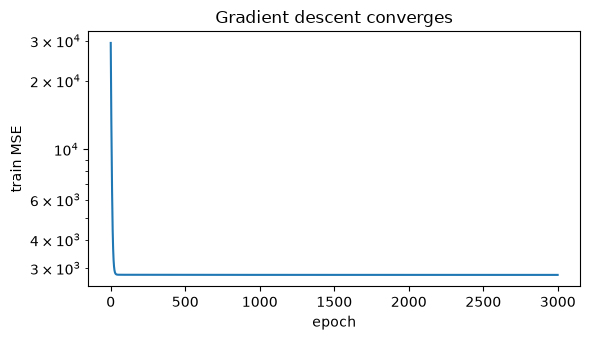

In [45]:
import matplotlib.pyplot as plt   # plotting is covered properly in module 02

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(loss_history)
ax.set(xlabel="epoch", ylabel="train MSE", title="Gradient descent converges", yscale="log")
plt.tight_layout()
plt.show()

**Stretch goals**
1. Add **L2 regularization** (ridge): closed form `w = solve(XᵀX + λI, Xᵀy)` (don't penalize the bias). How does test R² change for λ in `[0.1, 1, 10, 100]`?
2. Implement **mini-batch gradient descent** (batches of 32, reshuffled every epoch).
3. Try a **learning rate** that is too large (e.g. `0.5`) and explain what happens to the loss.

### 🗣️ How to talk about this in an interview
- "I implemented linear regression in pure NumPy two ways: least squares via `lstsq` and batch gradient descent with a vectorized gradient `2/n · Xᵀ(Xw − y)`."
- "I standardized with **training-set statistics only** to avoid leakage, and added a bias column."
- "Both reach test R² around the same value and clearly beat the mean-prediction baseline; I asserted GD converged within 1% of the exact RMSE."
- "Standardizing matters for gradient descent because features on different scales make the loss surface elongated, so one learning rate can't suit every direction."
- "Next I'd add ridge regularization, because features like `s1` and `s2` are strongly correlated."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Why is NumPy so much faster than Python lists for numerical work?**

<details><summary>Show answer</summary>

- **30-second answer:** Arrays store raw numbers of one type in contiguous memory, and operations run as compiled loops (often SIMD) instead of the Python interpreter checking and boxing every element.
- **Go deeper:** A list holds pointers to separate Python objects (~28 bytes per int + 8-byte pointer), so it is cache-unfriendly and ~4–5× bigger. Vectorized ufuncs avoid per-element function calls entirely.
- **❌ Common wrong answer:** "Because NumPy is multithreaded." Most element-wise ufuncs run single-threaded; only some linear-algebra calls use a multithreaded BLAS.

</details>

**Q2. What is the difference between a view and a copy? How do you tell which one you have?**

<details><summary>Show answer</summary>

- **30-second answer:** A view shares memory with the original (basic slicing, reshape, `.T`), so writes propagate; a copy is independent (boolean/fancy indexing, `.copy()`, `astype`).
- **Go deeper:** `np.shares_memory(a, b)` answers it definitively; `b.base is a` hints at it. Views make slicing O(1); use `.copy()` before modifying a slice you intend to keep separate.
- **❌ Common wrong answer:** "Slicing always copies, like Python lists."

</details>

**Q3. Explain the broadcasting rules. What shape does `(8, 1, 6) + (7, 1)` produce?**

<details><summary>Show answer</summary>

- **30-second answer:** Align shapes from the right; each dimension pair must be equal or one of them 1; missing dimensions count as 1. Here `(8,1,6)` and `(1,7,1)` → **`(8, 7, 6)`**.
- **Go deeper:** Broadcasting stretches size-1 dimensions *virtually* (stride 0), so no data is copied until a result is materialized. Watch the `(n,)` vs `(n,1)` trap, which silently produces an n×n matrix.
- **❌ Common wrong answer:** "Shapes are aligned from the left" or "the arrays must have the same number of dimensions."

</details>

**Q4. What does `axis=0` mean in `X.mean(axis=0)` for a `(n_samples, n_features)` matrix?**

<details><summary>Show answer</summary>

- **30-second answer:** Axis 0 is the one that gets collapsed, so the result has one mean per **feature** — shape `(n_features,)`.
- **Go deeper:** Use `keepdims=True` to keep shape `(1, n_features)` so the result broadcasts back safely against `X`.
- **❌ Common wrong answer:** "axis=0 means per row."

</details>

**Q5. When would you choose `float32` over `float64`?**

<details><summary>Show answer</summary>

- **30-second answer:** For large arrays and deep learning: half the memory, faster on GPUs, and the precision is enough for weights and activations.
- **Go deeper:** Mixed precision (float16/bfloat16) goes further but needs loss scaling or bfloat16 to avoid underflow. Keep float64 for numerically sensitive work like ill-conditioned linear algebra or financial sums.
- **❌ Common wrong answer:** "float32 is always less accurate so never use it."

</details>

**Q6. What is the difference between `*`, `np.dot`, and `@`?**

<details><summary>Show answer</summary>

- **30-second answer:** `*` is element-wise; `@` (`np.matmul`) is matrix multiplication and broadcasts over leading batch dimensions; `np.dot` matches `@` for 1-D and 2-D but behaves differently for higher dimensions.
- **Go deeper:** For `(batch, n, m) @ (batch, m, k)` → `(batch, n, k)` — the core of attention layers. Prefer `@` for readability and correct batching.
- **❌ Common wrong answer:** "`np.dot` and `@` are identical for all shapes."

</details>

### 💻 Coding

**Q7. Compute the pairwise Euclidean distance matrix between `A (n×d)` and `B (m×d)` without loops.**

<details><summary>Show answer</summary>

- **30-second answer:** `sq = (A**2).sum(1)[:, None] + (B**2).sum(1)[None, :] - 2 * A @ B.T; D = np.sqrt(np.maximum(sq, 0))`.
- **Go deeper:** The naive broadcast `A[:, None, :] - B[None, :, :]` is simpler but allocates an `(n, m, d)` array; the expansion trick needs only `(n, m)`. Clip at 0 because rounding can make tiny values negative.
- **❌ Common wrong answer:** Forgetting the clip (→ `nan` from `sqrt` of `-1e-12`) or mixing up `[:, None]` and `[None, :]`.

</details>

**Q8. Implement softmax. Why can the naive version return `nan`?**

<details><summary>Show answer</summary>

- **30-second answer:** `e = np.exp(z - z.max(axis=-1, keepdims=True)); return e / e.sum(axis=-1, keepdims=True)`. Large logits overflow `exp` to `inf`, and `inf / inf` is `nan`; shifting by the max keeps values ≤ 0 without changing the result.
- **Go deeper:** For cross-entropy loss use **log-softmax** via the log-sum-exp trick so you never take `log(0)`.
- **❌ Common wrong answer:** Normalizing along the wrong axis for batched input (forgetting `axis=-1, keepdims=True`).

</details>

**Q9. How do you get the indices of the top-k values in a huge array efficiently?**

<details><summary>Show answer</summary>

- **30-second answer:** `idx = np.argpartition(x, -k)[-k:]` is O(n); then sort just those k: `idx[np.argsort(x[idx])[::-1]]`.
- **Go deeper:** A full `argsort` is O(n log n). For streaming data use a heap of size k (`heapq.nlargest`).
- **❌ Common wrong answer:** Always doing `np.argsort(x)[-k:]`, or assuming `argpartition` returns the k items in sorted order.

</details>

### 🐛 Debugging Scenarios

**Q10. Your MSE looks reasonable, but `(y_pred - y_true).shape` is `(1000, 1000)`. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** `y_pred` is `(1000, 1)` and `y_true` is `(1000,)`; broadcasting created all pairwise differences. Flatten one of them (`y_pred.ravel()`) or reshape both to the same shape.
- **Go deeper:** Guard with `assert y_pred.shape == y_true.shape` in metric functions — cheap and catches this class of bug instantly.
- **❌ Common wrong answer:** "NumPy has a bug" or "just take the diagonal".

</details>

**Q11. After `patch = image[100:200, 100:200]; patch[:] = 0`, the original image has a black square. Why, and how do you fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** Basic slicing returns a view onto the same pixels. Use `image[100:200, 100:200].copy()` if you want to edit the patch independently.
- **Go deeper:** This is the same mechanism that makes cropping huge images instant. Confirm with `np.shares_memory(image, patch)`.
- **❌ Common wrong answer:** "Assignment with `[:]` always affects the original" — it's the slice being a view that matters.

</details>

**Q12. A colleague solves `A x = b` with `np.linalg.inv(A) @ b` and gets unstable results. What do you suggest?**

<details><summary>Show answer</summary>

- **30-second answer:** Use `np.linalg.solve(A, b)` (LU factorization), or `np.linalg.lstsq` if `A` is not square or is rank-deficient. Computing the inverse is slower and amplifies rounding error.
- **Go deeper:** Check the condition number with `np.linalg.cond(A)`; a huge value means small input noise causes big output changes — consider regularization (e.g. ridge adds λI).
- **❌ Common wrong answer:** "Switch to float128" — it doesn't fix an ill-conditioned problem.

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `np.arange(6).reshape(2, 3).sum(axis=0)`
<details><summary>Answer</summary>

`[3 5 7]` — axis 0 collapses the rows, leaving one sum per column.
</details>

**2.** What is the shape of `np.array([1, 2, 3]) + np.array([[10], [20]])`?
<details><summary>Answer</summary>

`(2, 3)` — `(3,)` becomes `(1, 3)` and `(2, 1)` stretches to `(2, 3)`.
</details>

**3.** `a = np.arange(6).reshape(2, 3); b = a[:, 1]; b[0] = 99; print(a[0, 1])`
<details><summary>Answer</summary>

`99` — `a[:, 1]` is a view.
</details>

**4.** `np.array([0.1 + 0.2]) == 0.3`
<details><summary>Answer</summary>

`array([False])` — floating-point rounding; use `np.isclose`.
</details>

**5.** `np.array([200], dtype=np.uint8) + 100`
<details><summary>Answer</summary>

`array([44], dtype=uint8)` — 300 wraps around modulo 256.
</details>

## 📚 Resources

### 📖 Official Docs
- [NumPy: the absolute basics for beginners](https://numpy.org/doc/stable/user/absolute_beginners.html) — the official gentle introduction
- [Broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) — rules with pictures
- [Copies and views](https://numpy.org/doc/stable/user/basics.copies.html) — exactly when NumPy copies
- [Random Generator](https://numpy.org/doc/stable/reference/random/generator.html) — the modern random API

### 🎥 Videos
- [Keith Galli — Complete Python NumPy Tutorial](https://www.youtube.com/watch?v=GB9ByFAIAH4) (~1 h) — hands-on walkthrough of arrays, indexing, math, and reshaping; good second pass after this notebook
- [freeCodeCamp — Python NumPy Tutorial for Beginners](https://www.youtube.com/watch?v=QUT1VHiLmmI) (~1 h) — slower-paced beginner course if a concept here didn't click
- [3Blue1Brown — Essence of Linear Algebra](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab) (16 short videos) — the visual intuition behind matrices, dot products, and eigenvectors

### 📄 Papers
- [Harris et al. (2020) — Array programming with NumPy, *Nature*](https://www.nature.com/articles/s41586-020-2649-2) — how NumPy's design (strides, broadcasting, views) works, from its maintainers

### 📘 Books & Courses
- [Python Data Science Handbook — Ch. 2 (free online)](https://jakevdp.github.io/PythonDataScienceHandbook/02.00-introduction-to-numpy.html) — Jake VanderPlas
- [From Python to NumPy (free book)](https://www.labri.fr/perso/nrougier/from-python-to-numpy/) — Nicolas Rougier, on thinking in vectors

### 🏋️ Practice
- [100 NumPy exercises](https://github.com/rougier/numpy-100) — graded from easy to hard, with solutions

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| Create | build arrays | `np.array`, `zeros`, `ones`, `arange` (step), `linspace` (count), `eye` |
| Inspect | size & type | `.shape`, `.ndim`, `.dtype`, `.nbytes`, `.astype()` |
| Index | select data | `a[i, j]`, `a[1:3]`, `a[mask]`, `a[[0, 2]]` |
| Views vs copies | memory sharing | slices/reshape = view · mask/fancy/`.copy()` = copy · `np.shares_memory` |
| Vectorize | math without loops | `+ - * /`, `np.sqrt/exp/log`, `np.where`, `np.maximum`, `np.clip` |
| Aggregate | reduce along an axis | `sum/mean/std/min/max/argmax(axis=…, keepdims=True)` |
| Broadcast | combine shapes | align right; equal or 1; `[:, np.newaxis]` |
| Reshape | change shape | `reshape(-1)`, `.T`, `ravel`, `concatenate` (existing axis), `stack` (new axis) |
| Linear algebra | matrices | `@`, `np.linalg.solve`, `lstsq`, `norm`, `eigh` — avoid `inv` |
| Random | reproducible randomness | `rng = np.random.default_rng(seed)`, `rng.normal/integers/permutation` |
| Sort & search | order / top-k | `np.sort`, `argsort`, `argpartition`, `unique(return_counts=True)` |
| Save | persist arrays | `np.save/load`, `savez_compressed` |

## ➡️ What's Next

**[02 · Pandas](02_Pandas.ipynb)** — NumPy gives you fast numbers; Pandas adds labelled columns, missing-value handling, group-by, and joins on top of NumPy arrays, which is how real tabular datasets are cleaned and explored.